In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import zz_feature_map
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from circuits import CPCircuit
from reservoirs import CPRC
from qiskit.circuit.library import ZZFeatureMap

In [3]:
window_size = 4
n_samples = 2000
tr = 0.75
itr = 20
a= 5
b = 100
taus = np.linspace(a,b,itr, dtype=int)
taus

array([  5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,
        70,  75,  80,  85,  90,  95, 100])

In [4]:
dim=window_size
zz_map = ZZFeatureMap(dim, reps=1, entanglement='linear', parameter_prefix='x')
cprc = CPRC(dim=dim, circuit=zz_map, execution_mode='simulation', kernel = True) #simulation
esn1 = ESNetwork(
    reservoir=cprc,
    dim=dim,
    regularization=1e-6,
    alpha=0.2,
    show_progress=True,
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6,
    cpk=True)

In [5]:
cprc = CPRC(dim=dim, execution_mode='simulation', kernel = True) #simulation
esn2 = ESNetwork(
    reservoir=cprc,
    dim=dim,
    regularization=1e-6,
    alpha=0.2,
    show_progress=True,
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6,
    cpk=True)

In [6]:
mserror1=[]
mserror2=[]
for i in range(20):
    X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = taus[i], window_size=window_size,prediction_horizon=20, plot=False)
    train_size = int(n_samples*tr)  # Training set size
    # Split into training and testing sets
    X_train_, X_test_ = X[:train_size], X[train_size:]
    y_train, y_test = Y[:train_size], Y[train_size:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_)
    X_test = scaler.transform(X_test_)

    esn1.fit(X_train, y_train)
    predictions1 = esn1.predict(X_test)

    esn2.fit(X_train, y_train)
    predictions2 = esn2.predict(X_test)

    rmse1 = mean_squared_error(y_test, predictions1)
    rmse2 = mean_squared_error(y_test, predictions2)
    mserror1.append(rmse1)
    mserror2.append(rmse2)
# print(predictions)

Prediction Progress: 100%|██████████| 477/477 [00:03<00:00, 120.44 sample/s]


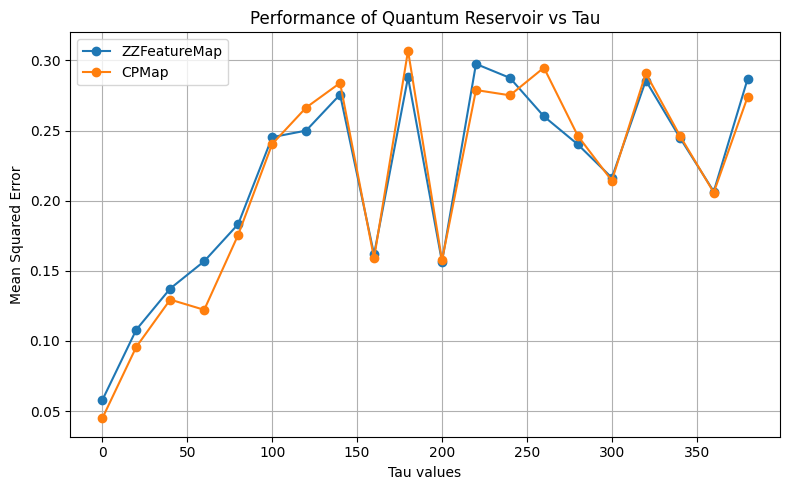

In [7]:
# CP_params = [-np.pi/3, i*np.pi/160, -np.pi/9, np.pi/7, np.pi/9, -np.pi/7]
param_values = [i*20 for i in range(len(taus))]
plt.figure(figsize=(8, 5))
plt.plot(param_values, mserror1, marker='o', linestyle='-', label="ZZFeatureMap")
plt.plot(param_values, mserror2, marker='o', linestyle='-', label="CPMap")
plt.xlabel("Tau values")
plt.ylabel("Mean Squared Error")
plt.title("Performance of Quantum Reservoir vs Tau")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [9]:
data = {
    "MSEs for ZZFeatureMap": mserror1,
    "MSEs for CPMap": mserror2,
}

# Optional: Save to file as JSON
import json
with open(f"MSE_WS_{window_size}.json", "w") as f:
    json.dump(data, f)